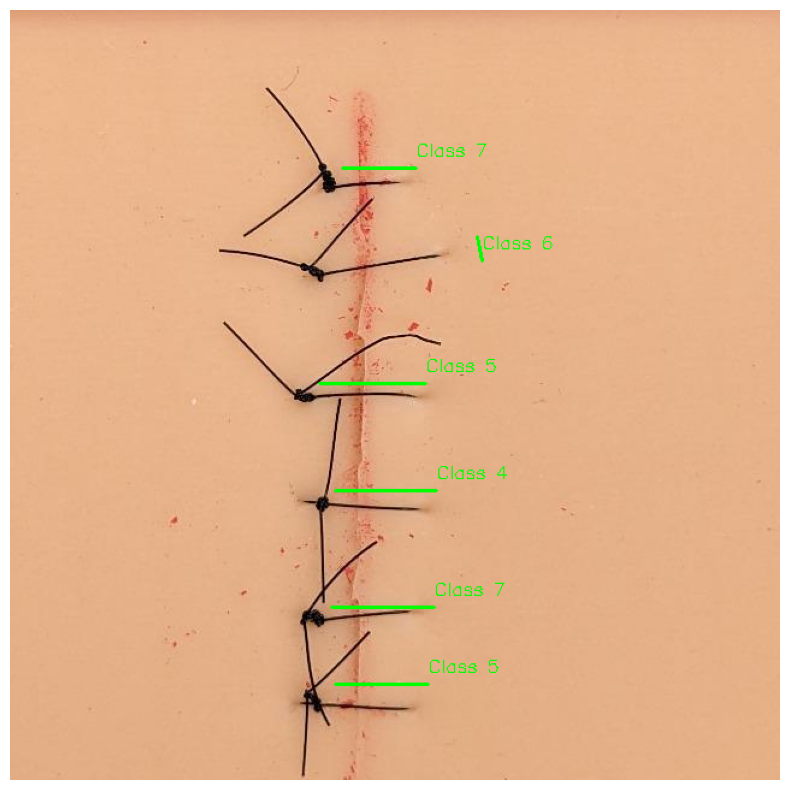

Suture 1 (Class 7): Angle to vertical = 90.00 degrees
Suture 2 (Class 5): Angle to vertical = 90.00 degrees
Suture 3 (Class 4): Angle to vertical = 90.00 degrees
Suture 4 (Class 7): Angle to vertical = 90.00 degrees
Suture 5 (Class 5): Angle to vertical = 90.00 degrees
Suture 6 (Class 6): Angle to vertical = 189.15 degrees


In [1]:
import numpy as np
from math import atan2, degrees
import cv2
import matplotlib.pyplot as plt

# Absolute paths for the image and label files
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
label_file = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\labels\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.txt"

# Load the image
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from path {image_path}. Please check the file path and try again.")
else:
    image_height, image_width, _ = image.shape

    # Define function to calculate angle with respect to the vertical
    def calculate_angle(x1, y1, x2, y2):
        # Convert coordinates to the actual image scale
        x1, y1 = x1 * image_width, y1 * image_height
        x2, y2 = x2 * image_width, y2 * image_height

        # Calculate the angle of the line with respect to the vertical (90 degrees)
        dx = x2 - x1
        dy = y2 - y1
        angle_radians = atan2(dy, dx)
        angle_degrees = abs(degrees(angle_radians) - 90)  # Deviation from 90 degrees
        return angle_degrees

    # Parse the label file, filter suture classes, and calculate angles
    suture_classes = {4, 5, 6, 7}  # Classes that represent sutures
    angles = []

    with open(label_file, "r") as file:
        for line in file:
            values = line.strip().split()
            class_id = int(values[0])

            # Filter for suture classes only
            if class_id in suture_classes:
                # Extract coordinates and calculate angle
                x1, y1, x2, y2, _, _, _, _ = map(float, values[1:])  # Using first two points as line segment
                angle = calculate_angle(x1, y1, x2, y2)
                angles.append((class_id, angle))

                # Draw the bounding box for visualization
                x1, y1 = int(x1 * image_width), int(y1 * image_height)
                x2, y2 = int(x2 * image_width), int(y2 * image_height)
                cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label_position = (x1, y1 - 10 if y1 > 20 else y1 + 10)
                cv2.putText(image, f"Class {class_id}", label_position, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Display the image with bounding boxes and angles
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # Print angles for each suture
    for i, (class_id, angle) in enumerate(angles, start=1):
        print(f"Suture {i} (Class {class_id}): Angle to vertical = {angle:.2f} degrees")
        


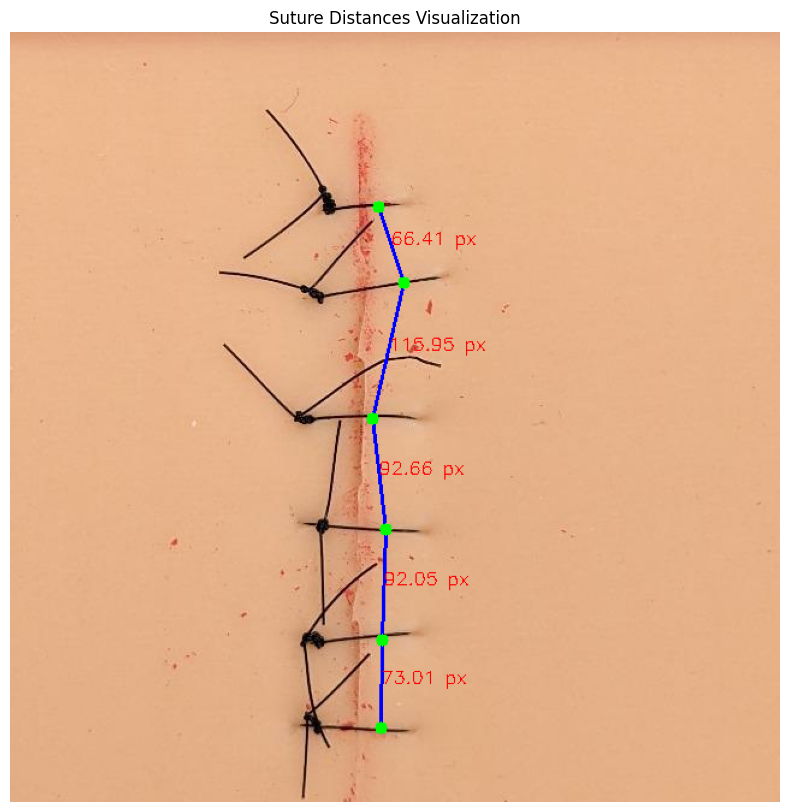

In [2]:
import cv2
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

# Paths
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
label_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\labels\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.txt"

# Load the image
image = cv2.imread(image_path)
if image is None:
    print("Error loading image.")
else:
    image_height, image_width = image.shape[:2]

    # Classes that correspond to sutures
    suture_classes = {4, 5, 6, 7}

    # Parse the label file and extract center points for sutures
    suture_centers = []
    with open(label_path, "r") as file:
        for line in file:
            values = line.strip().split()
            class_id = int(values[0])

            # Filter for suture classes only
            if class_id in suture_classes:
                # Calculate the center point of the bounding box (average of x and y coordinates)
                x1, y1 = float(values[1]), float(values[2])
                x2, y2 = float(values[3]), float(values[4])
                x3, y3 = float(values[5]), float(values[6])
                x4, y4 = float(values[7]), float(values[8])

                x_center = (x1 + x2 + x3 + x4) / 4
                y_center = (y1 + y2 + y3 + y4) / 4

                # Convert normalized coordinates to image dimensions
                x_center_px = int(x_center * image_width)
                y_center_px = int(y_center * image_height)
                suture_centers.append((x_center_px, y_center_px))

    # Sort suture centers by the y-coordinate to ensure vertical ordering
    suture_centers = sorted(suture_centers, key=lambda point: point[1])

    # Calculate distances between consecutive suture centers and visualize
    for i in range(len(suture_centers) - 1):
        x1, y1 = suture_centers[i]
        x2, y2 = suture_centers[i + 1]
        distance = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

        # Draw circles on suture centers
        cv2.circle(image, (x1, y1), 5, (0, 255, 0), -1)  # Green circle for the first point
        cv2.circle(image, (x2, y2), 5, (0, 255, 0), -1)  # Green circle for the next point

        # Draw line between consecutive suture centers
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue line between sutures

        # Display the distance on the line
        mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.putText(image, f"{distance:.2f} px", (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)  # Red text

    # Display the final suture centers without connections for single sutures
    for x, y in suture_centers:
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

    # Convert BGR image to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib for a polished look
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Suture Distances Visualization")
    plt.show()


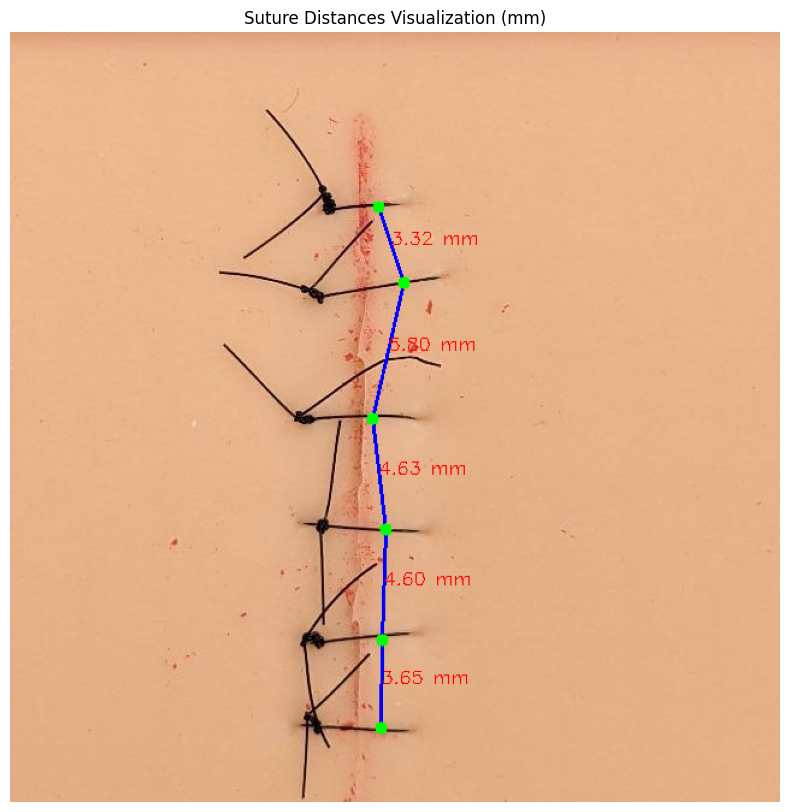

In [3]:
import cv2
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

# Paths
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
label_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\labels\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.txt"

# Load the image
image = cv2.imread(image_path)
if image is None:
    print("Error loading image.")
else:
    image_height, image_width = image.shape[:2]

    # Classes that correspond to sutures
    suture_classes = {4, 5, 6, 7}

    # Known suture diameter in mm (example)
    known_suture_diameter_mm = 0.5
    measured_suture_diameter_px = 10  # Example pixel measurement (you would measure this from the image)

    # Calculate conversion factor (mm per pixel)
    conversion_factor = known_suture_diameter_mm / measured_suture_diameter_px

    # Parse the label file and extract center points for sutures
    suture_centers = []
    with open(label_path, "r") as file:
        for line in file:
            values = line.strip().split()
            class_id = int(values[0])

            # Filter for suture classes only
            if class_id in suture_classes:
                # Calculate the center point of the bounding box (average of x and y coordinates)
                x1, y1 = float(values[1]), float(values[2])
                x2, y2 = float(values[3]), float(values[4])
                x3, y3 = float(values[5]), float(values[6])
                x4, y4 = float(values[7]), float(values[8])

                x_center = (x1 + x2 + x3 + x4) / 4
                y_center = (y1 + y2 + y3 + y4) / 4

                # Convert normalized coordinates to image dimensions
                x_center_px = int(x_center * image_width)
                y_center_px = int(y_center * image_height)
                suture_centers.append((x_center_px, y_center_px))

    # Sort suture centers by the y-coordinate to ensure vertical ordering
    suture_centers = sorted(suture_centers, key=lambda point: point[1])

    # Calculate distances between consecutive suture centers and convert to mm
    for i in range(len(suture_centers) - 1):
        x1, y1 = suture_centers[i]
        x2, y2 = suture_centers[i + 1]
        distance_px = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        distance_mm = distance_px * conversion_factor  # Convert to mm

        # Draw circles on suture centers
        cv2.circle(image, (x1, y1), 5, (0, 255, 0), -1)
        cv2.circle(image, (x2, y2), 5, (0, 255, 0), -1)

        # Draw line between consecutive suture centers
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Display the distance on the line in mm
        mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.putText(image, f"{distance_mm:.2f} mm", (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    # Display the final suture centers without connections for single sutures
    for x, y in suture_centers:
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

    # Convert BGR image to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib for a polished look
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Suture Distances Visualization (mm)")
    plt.show()


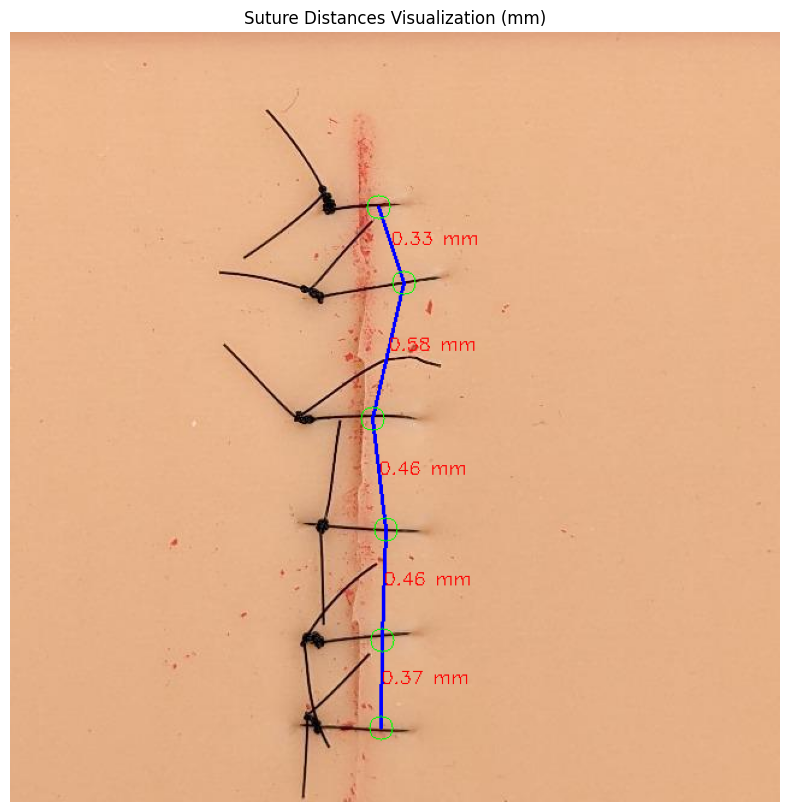

In [4]:
import cv2
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

# Paths
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
label_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\labels\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.txt"

# Load the image
image = cv2.imread(image_path)
if image is None:
    print("Error loading image.")
else:
    image_height, image_width = image.shape[:2]

    # Classes that correspond to sutures
    suture_classes = {4, 5, 6, 7}

    # Known real-world suture width
    known_suture_width_mm = 0.05  # 0.05 mm (assumed)

    # Assume an estimated suture width in pixels by visually inspecting the image
    estimated_suture_width_px = 10  # You would adjust this value based on actual measurement in the image

    # Calculate conversion factor (mm per pixel)
    conversion_factor = known_suture_width_mm / estimated_suture_width_px

    # Parse the label file and extract center points for sutures
    suture_centers = []
    with open(label_path, "r") as file:
        for line in file:
            values = line.strip().split()
            class_id = int(values[0])

            # Filter for suture classes only
            if class_id in suture_classes:
                # Calculate the center point of the bounding box (average of x and y coordinates)
                x1, y1 = float(values[1]), float(values[2])
                x2, y2 = float(values[3]), float(values[4])
                x3, y3 = float(values[5]), float(values[6])
                x4, y4 = float(values[7]), float(values[8])

                x_center = (x1 + x2 + x3 + x4) / 4
                y_center = (y1 + y2 + y3 + y4) / 4

                # Convert normalized coordinates to image dimensions
                x_center_px = int(x_center * image_width)
                y_center_px = int(y_center * image_height)
                suture_centers.append((x_center_px, y_center_px))

    # Sort suture centers by the y-coordinate to ensure vertical ordering
    suture_centers = sorted(suture_centers, key=lambda point: point[1])

    # Calculate distances between consecutive suture centers and convert to mm
    for i in range(len(suture_centers) - 1):
        x1, y1 = suture_centers[i]
        x2, y2 = suture_centers[i + 1]
        distance_px = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        distance_mm = distance_px * conversion_factor  # Convert to mm

        # Draw circles on suture centers with radius equal to estimated suture width in pixels
        cv2.circle(image, (x1, y1), estimated_suture_width_px, (0, 255, 0), 1)  # Green circle as reference
        cv2.circle(image, (x2, y2), estimated_suture_width_px, (0, 255, 0), 1)

        # Draw line between consecutive suture centers
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Display the distance on the line in mm
        mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.putText(image, f"{distance_mm:.2f} mm", (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    # Display the final suture centers without connections for single sutures
    for x, y in suture_centers:
        cv2.circle(image, (x, y), estimated_suture_width_px, (0, 255, 0), 1)

    # Convert BGR image to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib for a polished look
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Suture Distances Visualization (mm)")
    plt.show()


In [5]:
import cv2
import numpy as np

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Find contours in the edge-detected image
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter and analyze contours to find suture width
    suture_widths = []
    for contour in contours:
        # Filter small contours to ignore noise
        if cv2.contourArea(contour) > 10:
            # Fit a bounding rectangle around the contour
            x, y, w, h = cv2.boundingRect(contour)

            # Assuming sutures are thin, we consider the smaller dimension as the width
            suture_width = min(w, h)
            suture_widths.append(suture_width)

            # Draw the contour and bounding box for visualization (optional)
            cv2.drawContours(image, [contour], -1, (0, 255, 0), 1)
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 1)

    # Calculate the average width of the suture from the contours
    if suture_widths:
        average_suture_width_px = sum(suture_widths) / len(suture_widths)
        print(f"Estimated average suture width: {average_suture_width_px:.2f} pixels")
    else:
        print("No sutures detected.")

    # Display the result (optional)
    cv2.imshow("Suture Width Detection", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Estimated average suture width: 29.53 pixels


In [6]:
import cv2
import numpy as np

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Focus on a horizontal region in the middle of the image to isolate the sutures
    height, width = edges.shape
    center_region_height = 20  # Adjust height for a narrow band around the center
    center_y = height // 2

    # Extract only a horizontal band around the incision line
    suture_band = edges[center_y - center_region_height : center_y + center_region_height, :]

    # Find contours in this narrow region
    contours, _ = cv2.findContours(suture_band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Measure width of each suture by calculating the leftmost and rightmost points in each contour
    suture_widths = []
    for contour in contours:
        if cv2.contourArea(contour) > 5:  # Ignore small contours (noise)
            # Find the leftmost and rightmost points of the contour
            leftmost = tuple(contour[contour[:, :, 0].argmin()][0])
            rightmost = tuple(contour[contour[:, :, 0].argmax()][0])

            # Calculate the distance between these points (width of the suture)
            suture_width_px = abs(rightmost[0] - leftmost[0])
            suture_widths.append(suture_width_px)

            # Draw the width measurement on the original image for visualization
            # Draw a line between the leftmost and rightmost points
            cv2.line(image, (leftmost[0], center_y), (rightmost[0], center_y), (255, 0, 0), 2)
            cv2.circle(image, (leftmost[0], center_y), 5, (0, 255, 0), -1)
            cv2.circle(image, (rightmost[0], center_y), 5, (0, 255, 0), -1)

            # Display each suture width in pixels above the line
            mid_x = (leftmost[0] + rightmost[0]) // 2
            cv2.putText(image, f"{suture_width_px:.2f} px", (mid_x, center_y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    # Calculate the average width of the suture from all contours
    if suture_widths:
        average_suture_width_px = sum(suture_widths) / len(suture_widths)
        print(f"Estimated average suture width: {average_suture_width_px:.2f} pixels")
    else:
        print("No sutures detected.")

    # Display the result with markings for verification
    cv2.imshow("Suture Width Detection", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Estimated average suture width: 67.33 pixels


In [7]:
import cv2
import numpy as np

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Focus on a horizontal region in the middle of the image to isolate the sutures
    height, width = edges.shape
    center_region_height = 20  # Adjust height for a narrow band around the center
    center_y = height // 2

    # Extract only a horizontal band around the incision line
    suture_band = edges[center_y - center_region_height : center_y + center_region_height, :]

    # Find contours in this narrow region
    contours, _ = cv2.findContours(suture_band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Analyze coverage of the 2-pixel line for each suture
    suture_widths = []
    line_thickness = 2  # Our reference line thickness in pixels

    for contour in contours:
        if cv2.contourArea(contour) > 5:  # Ignore small contours (noise)
            # Find the topmost and bottommost points of the contour
            topmost = tuple(contour[contour[:, :, 1].argmin()][0])
            bottommost = tuple(contour[contour[:, :, 1].argmax()][0])

            # Draw a 2-pixel-thick line across the suture
            cv2.line(image, (width // 2, topmost[1] + center_y - center_region_height), 
                     (width // 2, bottommost[1] + center_y - center_region_height), (255, 0, 0), line_thickness)

            # Extract a region of interest around the line
            y_min = topmost[1] + center_y - center_region_height
            y_max = bottommost[1] + center_y - center_region_height
            line_region = gray[y_min:y_max, width // 2 - 1:width // 2 + 1]  # Extract the area around the 2-pixel line

            # Count the number of non-zero pixels (suture pixels) along the line
            suture_coverage = cv2.countNonZero(line_region)

            # Estimate suture width in pixels based on coverage
            estimated_suture_width = suture_coverage / line_thickness
            suture_widths.append(estimated_suture_width)

            # Display the estimated suture width on the image
            mid_y = (topmost[1] + bottommost[1]) // 2 + center_y - center_region_height
            cv2.putText(image, f"{estimated_suture_width:.2f} px", (width // 2 + 10, mid_y), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    # Calculate the average suture width
    if suture_widths:
        average_suture_width_px = sum(suture_widths) / len(suture_widths)
        print(f"Estimated average suture width: {average_suture_width_px:.2f} pixels")
    else:
        print("No sutures detected.")

    # Display the result with markings for verification
    cv2.imshow("Suture Width Detection", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Estimated average suture width: 20.00 pixels


In [8]:
import cv2
import numpy as np

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Detect lines using probabilistic Hough Line Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)

    # Find the longest line among detected lines
    longest_line = None
    max_length = 0
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            line_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
            if line_length > max_length:
                max_length = line_length
                longest_line = (x1, y1, x2, y2)

    # Draw the longest line on the image
    if longest_line:
        x1, y1, x2, y2 = longest_line
        cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green line for the longest suture

        # Extract a narrow region around the 2-pixel line for analysis
        line_thickness = 2
        mask = np.zeros_like(gray)
        cv2.line(mask, (x1, y1), (x2, y2), 255, line_thickness)

        # Calculate coverage by counting the number of non-zero pixels on the line and within the suture
        suture_coverage = cv2.countNonZero(cv2.bitwise_and(mask, edges))
        total_line_pixels = cv2.countNonZero(mask)

        # Calculate percentage coverage of the 2-pixel line on the suture
        if total_line_pixels > 0:
            coverage_ratio = suture_coverage / total_line_pixels
            estimated_suture_width = line_thickness / coverage_ratio
            print(f"Estimated suture width: {estimated_suture_width:.2f} pixels based on {coverage_ratio:.2%} coverage")
        else:
            print("No coverage detected, unable to estimate width.")
    else:
        print("No suture line detected.")

    # Display the result for visualization
    cv2.imshow("Longest Suture Line Detection", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Estimated suture width: 5.98 pixels based on 33.43% coverage


In [9]:
import cv2
import numpy as np
import math

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Detect lines using probabilistic Hough Line Transform with optimized parameters
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=20, maxLineGap=5)

    # Store coverage ratios and estimated widths for all suitable line segments
    coverage_ratios = []
    estimated_widths = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            line_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            # Calculate the angle of the line to filter for near-vertical lines
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if 80 < angle < 100 or 260 < angle < 280:
                # Draw the line on the image for visualization
                cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 1)  # Green line for suture

                # Create a mask for a 2-pixel wide line along the detected suture
                line_thickness = 2
                mask = np.zeros_like(gray)
                cv2.line(mask, (x1, y1), (x2, y2), 255, line_thickness)

                # Calculate coverage of the 2-pixel line within the suture edges
                suture_coverage = cv2.countNonZero(cv2.bitwise_and(mask, edges))
                total_line_pixels = cv2.countNonZero(mask)

                if total_line_pixels > 0:
                    # Calculate and store coverage ratio for this line segment
                    coverage_ratio = suture_coverage / total_line_pixels
                    coverage_ratios.append(coverage_ratio)

                    # Estimate suture width for this segment based on coverage
                    estimated_width = line_thickness / coverage_ratio
                    estimated_widths.append(estimated_width)

    # Calculate the average suture width from all relevant line segments
    if estimated_widths:
        average_suture_width_px = sum(estimated_widths) / len(estimated_widths)
        average_coverage_ratio = sum(coverage_ratios) / len(coverage_ratios)
        print(f"Average estimated suture width: {average_suture_width_px:.2f} pixels")
        print(f"Average coverage ratio: {average_coverage_ratio:.2%}")
    else:
        print("No suitable suture lines detected.")

    # Display the result for visualization
    cv2.imshow("Optimized Suture Line Detection with Multiple Segments", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Average estimated suture width: 5.87 pixels
Average coverage ratio: 34.16%


In [10]:
import cv2
import numpy as np
import math

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply edge detection (Canny)
    edges = cv2.Canny(blurred, 50, 150)

    # Detect lines using probabilistic Hough Line Transform with optimized parameters
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=40, minLineLength=20, maxLineGap=5)

    # Store coverage ratios and estimated widths for all suitable line segments
    coverage_ratios = []
    estimated_widths = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            line_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            # Calculate the angle of the line to filter for near-vertical lines
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if 80 < angle < 100 or 260 < angle < 280:
                # Draw the line on the image for visualization
                cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 1)  # Green line for suture

                # Create a mask that accurately follows the contour of the detected line
                line_thickness = 2
                mask = np.zeros_like(gray)
                cv2.line(mask, (x1, y1), (x2, y2), 255, line_thickness)

                # Calculate coverage of the 2-pixel line within the suture edges
                overlap_area = cv2.bitwise_and(mask, edges)
                suture_coverage = cv2.countNonZero(overlap_area)
                total_line_pixels = cv2.countNonZero(mask)

                if total_line_pixels > 0:
                    # Calculate and store coverage ratio for this line segment
                    coverage_ratio = suture_coverage / total_line_pixels
                    coverage_ratios.append(coverage_ratio)

                    # Estimate suture width for this segment based on coverage
                    estimated_width = line_thickness / max(coverage_ratio, 1e-5)  # Avoid division by zero
                    estimated_widths.append(estimated_width)

    # Calculate the average suture width from all relevant line segments
    if estimated_widths:
        average_suture_width_px = sum(estimated_widths) / len(estimated_widths)
        average_coverage_ratio = sum(coverage_ratios) / len(coverage_ratios)
        print(f"Average estimated suture width: {average_suture_width_px:.2f} pixels")
        print(f"Average coverage ratio: {average_coverage_ratio:.2%}")
    else:
        print("No suitable suture lines detected.")

    # Display the result for visualization
    cv2.imshow("Optimized Suture Line Detection with Improved Coverage Calculation", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Average estimated suture width: 5.84 pixels
Average coverage ratio: 34.38%


In [11]:
import cv2
import numpy as np

# Load the image
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error loading image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply binary thresholding to isolate dark sutures
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)

    # Apply morphological operations to improve suture line continuity
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Find contours of the suture
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Calculate the width of each suture by analyzing perpendicular profiles
    suture_widths = []
    for contour in contours:
        # Filter out small contours based on area to ignore noise
        if cv2.contourArea(contour) > 20:
            # Fit a bounding box around the contour
            x, y, w, h = cv2.boundingRect(contour)
            
            # Take multiple intensity profiles across the width of the suture
            profile_widths = []
            num_samples = 10  # Number of profiles to take across the bounding box
            for i in range(num_samples):
                # Calculate y-coordinate for the cross-section within the bounding box
                sample_y = y + int(i * h / num_samples)
                
                # Extract intensity values across the width of the bounding box at this y
                intensity_profile = gray[sample_y, x:x + w]
                
                # Measure the width by identifying dark pixels in the profile
                dark_pixels = np.where(intensity_profile < 50)[0]  # Threshold to detect dark pixels
                if len(dark_pixels) > 1:
                    width = dark_pixels[-1] - dark_pixels[0]  # Width between first and last dark pixel
                    profile_widths.append(width)

            # Average the widths from all profiles for this suture segment
            if profile_widths:
                average_width = np.mean(profile_widths)
                suture_widths.append(average_width)

                # Draw the bounding box and display the width on the image for visualization
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(image, f"{average_width:.2f}px", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    # Calculate the average width of all suture segments
    if suture_widths:
        overall_average_width = np.mean(suture_widths)
        print(f"Overall estimated average suture width: {overall_average_width:.2f} pixels")
    else:
        print("No sutures detected.")

    # Display the result
    cv2.imshow("Suture Width Detection with Profile Intensity Analysis", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Overall estimated average suture width: 30.74 pixels


Estimated average suture width: 84.60 pixels
Conversion factor: 0.0591 mm per pixel


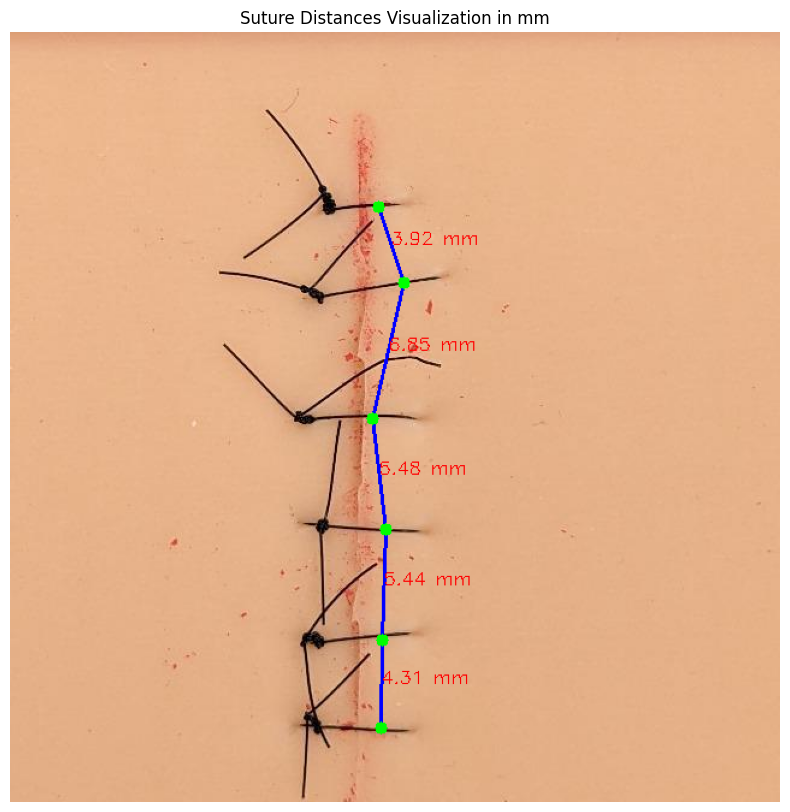

In [12]:
import cv2
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

# Paths
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\images\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg"
label_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\labeled_data_all\\valid\\labels\\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.txt"

# Load the image
image = cv2.imread(image_path)
if image is None:
    print("Error loading image.")
else:
    image_height, image_width = image.shape[:2]

    # Calculate suture width in pixels
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    suture_widths = []
    for contour in contours:
        if cv2.contourArea(contour) > 20:
            x, y, w, h = cv2.boundingRect(contour)
            suture_widths.append(min(w, h))

    if suture_widths:
        average_suture_width_px = sum(suture_widths) / len(suture_widths)
        print(f"Estimated average suture width: {average_suture_width_px:.2f} pixels")
        
        # Set the real width of the suture to 0.05 mm
        real_suture_width_mm = 5  # 100% width in mm
        px_to_mm = real_suture_width_mm / average_suture_width_px
        print(f"Conversion factor: {px_to_mm:.4f} mm per pixel")
    else:
        print("No sutures detected.")
        px_to_mm = 1  # Default to 1 if no conversion is possible

    # Classes that correspond to sutures
    suture_classes = {4, 5, 6, 7}

    # Parse the label file and extract center points for sutures
    suture_centers = []
    with open(label_path, "r") as file:
        for line in file:
            values = line.strip().split()
            class_id = int(values[0])

            if class_id in suture_classes:
                x1, y1 = float(values[1]), float(values[2])
                x2, y2 = float(values[3]), float(values[4])
                x3, y3 = float(values[5]), float(values[6])
                x4, y4 = float(values[7]), float(values[8])

                x_center = (x1 + x2 + x3 + x4) / 4
                y_center = (y1 + y2 + y3 + y4) / 4

                x_center_px = int(x_center * image_width)
                y_center_px = int(y_center * image_height)
                suture_centers.append((x_center_px, y_center_px))

    suture_centers = sorted(suture_centers, key=lambda point: point[1])

    for i in range(len(suture_centers) - 1):
        x1, y1 = suture_centers[i]
        x2, y2 = suture_centers[i + 1]
        distance_px = sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        distance_mm = distance_px * px_to_mm

        cv2.circle(image, (x1, y1), 5, (0, 255, 0), -1)
        cv2.circle(image, (x2, y2), 5, (0, 255, 0), -1)
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.putText(image, f"{distance_mm:.2f} mm", (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    for x, y in suture_centers:
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Suture Distances Visualization in mm")
    plt.show()


In [13]:
import math
import cv2
import numpy as np

def calculate_angle_with_horizontal(x1, y1, x2, y2):
    """
    Calculates the angle (in degrees) between the line formed by (x1, y1) and (x2, y2)
    and the horizontal axis, corrected to be between 0-90 degrees.
    """
    delta_x = x2 - x1
    delta_y = y2 - y1
    angle_rad = math.atan2(abs(delta_y), abs(delta_x))  # Use absolute values to ensure angles are within 0-90
    angle_deg = math.degrees(angle_rad)  # Convert to degrees
    return angle_deg

def process_and_visualize(image_path, label_file_path, output_image_path):
    """
    Processes a label file, calculates the angles of selected classes (7, 8, 9, 10),
    and visualizes them on the provided image.
    """
    # Load the image
    image = cv2.imread(image_path)
    h, w = image.shape[:2]  # Image dimensions

    # Selected classes to process
    selected_classes = {7, 8, 9, 10}
    white_color = (255, 255, 255)  # RGB for white

    # Read the label file
    with open(label_file_path, 'r') as file:
        for line in file:
            data = line.strip().split()
            if len(data) == 9:  # Format: class x1 y1 x2 y2 x3 y3 x4 y4
                class_id = int(data[0])  # Class ID
                if class_id in selected_classes:
                    coords = list(map(float, data[1:]))
                    # Convert normalized coordinates to absolute pixel values
                    x1, y1 = int(coords[0] * w), int(coords[1] * h)
                    x2, y2 = int(coords[2] * w), int(coords[3] * h)
                    x3, y3 = int(coords[4] * w), int(coords[5] * h)
                    x4, y4 = int(coords[6] * w), int(coords[7] * h)

                    # Calculate the angle of the edge between (x1, y1) and (x2, y2)
                    angle = calculate_angle_with_horizontal(x1, y1, x2, y2)

                    # Draw the OBB on the image
                    points = [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]
                    for i in range(4):
                        cv2.line(image, points[i], points[(i + 1) % 4], (0, 255, 0), 2)

                    # Annotate the image with the angle (to the right of the bounding box)
                    text = f"{angle:.2f} deg"
                    text_x = max(x1, x2, x3, x4) + 10  # Place text slightly to the right of the bounding box
                    text_y = (y1 + y3) // 2  # Center vertically with respect to the bounding box
                    cv2.putText(image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, white_color, 1)

    # Save the annotated image
    cv2.imwrite(output_image_path, image)
    print(f"Annotated image saved to {output_image_path}")

# Paths
image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\new_ignore\\valid\\images\\s_img_15_jpg.rf.c9ff21eec29f20bdf1558304545b5ef0.jpg"
label_file_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\new_ignore\\valid\\labels\\s_img_15_jpg.rf.c9ff21eec29f20bdf1558304545b5ef0.txt"
output_image_path = "C:\\Users\\shaki\\Documents\\VSCode\\ML Based Suture Pad Analysis\\ML-based-suture-pad-analysis\\data\\new_ignore\\output_annotated_image.jpg"

# Process and visualize
process_and_visualize(image_path, label_file_path, output_image_path)

Annotated image saved to C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\new_ignore\output_annotated_image.jpg
